In [4]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from skimage.feature import hog
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────
base_path     = "/Users/mrittikadutta/parkinsons_disease_detection"
healthy_path  = os.path.join(base_path, "Dataset", "Healthy")
parkinson_path = os.path.join(base_path, "Dataset", "Parkinson")


In [6]:
# ── HOG feature extraction ─────────────────────────────────────────────────
def extract_hog_features(path, label):
    features, labels = [], []
    for img_name in tqdm(os.listdir(path), desc=f"Label {label}"):
        if not img_name.lower().endswith('.png'):
            continue
        img = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (128, 128))
        feat = hog(img,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   block_norm='L2-Hys')
        features.append(feat)
        labels.append(label)
    return features, labels


In [7]:

print("Extracting HOG features...")
hf, hl = extract_hog_features(healthy_path,  0)
pf, pl = extract_hog_features(parkinson_path, 1)

X = np.array(hf + pf)
y = np.array(hl + pl)
print(f"Feature vector shape: {X.shape}")



Extracting HOG features...


Label 1: 100%|██████████| 1632/1632 [00:33<00:00, 48.32it/s]


Feature vector shape: (3264, 8100)


In [10]:
# ── Split + scale ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [11]:
# Fast SVM - skip grid search, use known good defaults
print("\nTraining SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', 
          class_weight='balanced', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Healthy','Parkinson']))



Training SVM...
SVM Accuracy: 0.9632
              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96       327
   Parkinson       0.96      0.96      0.96       326

    accuracy                           0.96       653
   macro avg       0.96      0.96      0.96       653
weighted avg       0.96      0.96      0.96       653



In [12]:

# ── Random Forest ──────────────────────────────────────────────────────────
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Healthy','Parkinson']))


Training Random Forest...
Random Forest Accuracy: 0.8591
              precision    recall  f1-score   support

     Healthy       0.83      0.90      0.86       327
   Parkinson       0.89      0.82      0.85       326

    accuracy                           0.86       653
   macro avg       0.86      0.86      0.86       653
weighted avg       0.86      0.86      0.86       653



In [16]:
X_scaled = scaler.fit_transform(X)
cv_svm = cross_val_score(svm, X_scaled, y, cv=5, scoring='accuracy')
cv_rf  = cross_val_score(rf,  X_scaled, y, cv=5, scoring='accuracy')
print(f"SVM  5-fold CV: {cv_svm.mean():.4f} ± {cv_svm.std():.4f}")
print(f"RF   5-fold CV: {cv_rf.mean():.4f}  ± {cv_rf.std():.4f}")


SVM  5-fold CV: 0.9770 ± 0.0159
RF   5-fold CV: 0.8756  ± 0.0093


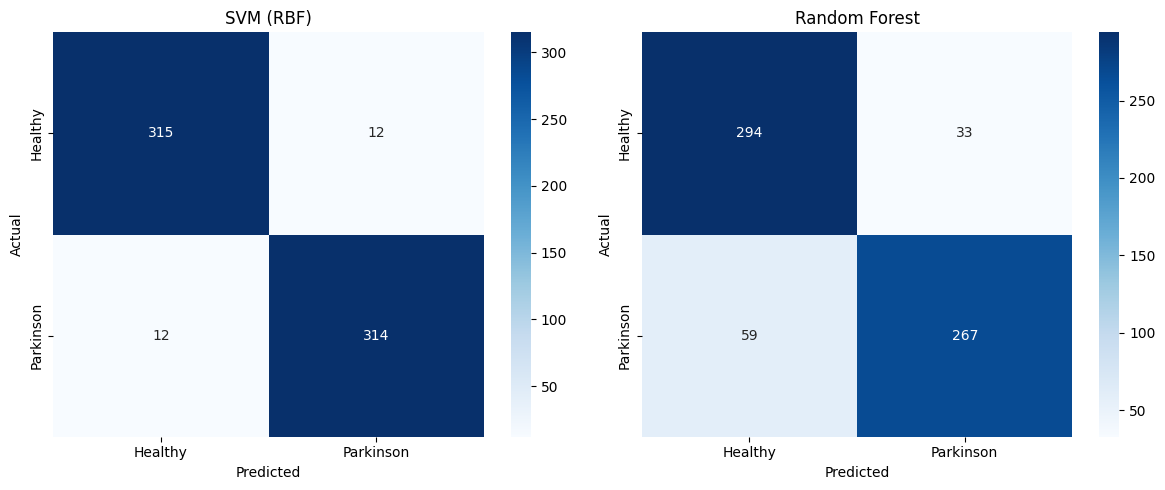

In [17]:
# ── Confusion matrices ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in zip(axes,
                            [y_pred_svm, y_pred_rf],
                            ['SVM (RBF)', 'Random Forest']):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Healthy', 'Parkinson'],
                yticklabels=['Healthy', 'Parkinson'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()